In [1]:
%pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/69.5 MB 1.4 MB/s eta 0:00:50
    --------------------------------------- 1.0/69.5 MB 1.3 MB/s eta 0:00:54
    --------------------------------------- 1.6/69.5 MB 1.5 MB/s eta 0:00:45
   - -------------------------------------- 2.9/69.5 MB 2.4 MB/s eta 0:00:29
   -- ------------------------------------- 4.2/69.5 MB 3.0 MB/s eta 0:00:22
   --- ------------------------------------ 6.3/69.5 MB 3.9 MB/s eta 0:00:17
   ---- ----------------------------------- 7.1/69.5 MB 4.1 MB/s eta 0:00:16
   ---- ----------------------------------- 7.3/69.5 MB 3.8 MB/s eta 0:00:17
   ---- ----------------------------------- 7.6/69.5 MB 3.4 MB/s eta 0:00:19
   ---- ----------------------------------- 7.6/69.5 MB 3.4 MB/s eta 0:00:19
   ---- ------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Load the Dataset
df = pd.read_csv("../data/processed/ltv_dataset.csv")
df.head()

#Check dataset shape:

df.shape

#Check columns and datatypes:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customerID       7032 non-null   str    
 1   gender           7032 non-null   str    
 2   SeniorCitizen    7032 non-null   int64  
 3   Partner          7032 non-null   str    
 4   Dependents       7032 non-null   str    
 5   tenure           7032 non-null   int64  
 6   PhoneService     7032 non-null   str    
 7   InternetService  7032 non-null   str    
 8   Contract         7032 non-null   str    
 9   MonthlyCharges   7032 non-null   float64
 10  TotalCharges     7032 non-null   float64
 11  Churn            7032 non-null   str    
 12  LTV              7032 non-null   float64
dtypes: float64(3), int64(2), str(8)
memory usage: 714.3 KB


In [4]:
#Define Features and Target

#Your target variable is still:

target = "LTV"

#Create X and y:

X = df.drop(columns=["LTV"])
y = df["LTV"]

#Remove customerID because it is just an identifier:

X = X.drop(columns=["customerID"])

In [5]:
#Define Numerical and Categorical Features

#Use the same feature split as previous days so all models are trained consistently.

#Numerical features
numerical_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "SeniorCitizen"
]
#Categorical features
categorical_features = [
    col for col in X.columns if col not in numerical_features
]

#Check them:

print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)

Numerical Features: ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
Categorical Features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'InternetService', 'Contract', 'Churn']


In [6]:
#Create Train-Test Split

#Use the same split as earlier models so you can compare results fairly.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

#Check the shapes:

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5625, 11)
(1407, 11)
(5625,)
(1407,)


In [7]:
#Create Preprocessing Pipelines
#Numeric pipeline
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)
#Categorical pipeline
categorical_transformer = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)
#Combine using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [8]:
#10: Create the XGBoost Pipeline

#Now build the full pipeline with preprocessing + XGBoost.

xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=5,
            random_state=42,
            objective="reg:squarederror"
        ))
    ]
)

In [9]:
#Train the XGBoost Regressor
xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['gender','SeniorCitizen','Partner',...,'MonthlyCharges','TotalCharges', 'Churn']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset 

In [10]:
#Make Predictions
#Predict on training set

y_train_pred = xgb_model.predict(X_train)

#Predict on test set
y_test_pred = xgb_model.predict(X_test)

#Preview predictions:

y_test_pred[:10]

array([1484.5997 ,  468.4104 , 1382.4861 , 2024.1172 ,  157.88065,
         94.86185, 4086.4727 , 1390.4749 , 1815.152  , 5546.097  ],
      dtype=float32)

In [11]:
#Evaluate the XGBoost Model

#Now compute the standard regression metrics.

#MAE
mae = mean_absolute_error(y_test, y_test_pred)
print("MAE:", mae)
#MSE
mse = mean_squared_error(y_test, y_test_pred)
print("MSE:", mse)

#RMSE
rmse = np.sqrt(mse)
print("RMSE:", rmse)
#R² Score
r2 = r2_score(y_test, y_test_pred)
print("R2 Score:", r2)

MAE: 42.65922331305032
MSE: 3892.5558312986127
RMSE: 62.39035046622685
R2 Score: 0.9992468194700341


In [12]:
#Create a Metrics Summary Table
xgb_metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2 Score"],
    "Value": [mae, mse, rmse, r2]
})

xgb_metrics

,Metric,Value
0,MAE,42.659223
1,MSE,3892.555831
2,RMSE,62.390350
3,R2 Score,0.999247


In [13]:
#Compare Actual vs Predicted Values
xgb_results = pd.DataFrame({
    "Actual_LTV": y_test.values,
    "Predicted_LTV": y_test_pred
})

xgb_results.head(10)

,Actual_LTV,Predicted_LTV
0,1525.00,1484.599731
1,469.30,468.410400
2,1329.25,1382.486084
3,2036.85,2024.117188
4,176.70,157.880646
5,89.40,94.861847
6,4204.20,4086.472656
7,1372.50,1390.474854
8,1807.00,1815.151978
9,5626.50,5546.097168


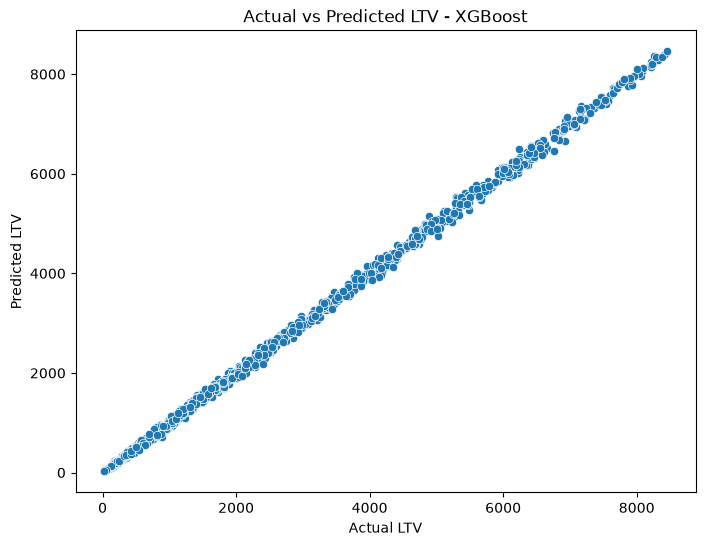

In [14]:
#Plot Actual vs Predicted
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_test_pred)
plt.xlabel("Actual LTV")
plt.ylabel("Predicted LTV")
plt.title("Actual vs Predicted LTV - XGBoost")
plt.show()

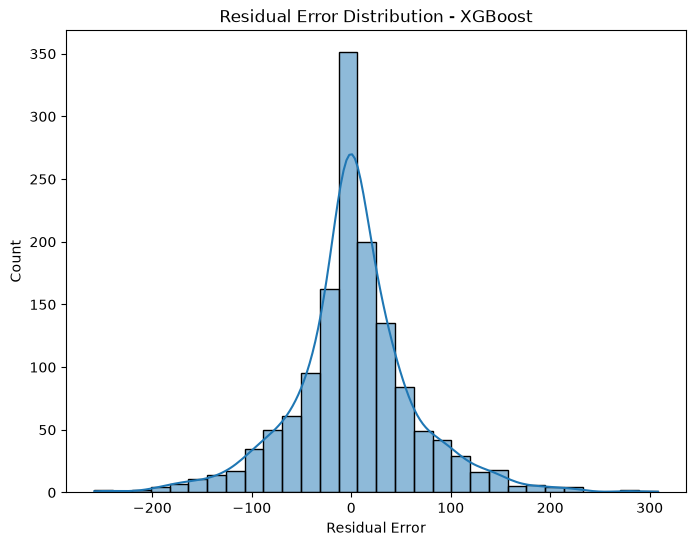

In [15]:
#Plot Residual Errors

#Residuals = Actual − Predicted

residuals = y_test - y_test_pred

plt.figure(figsize=(8,6))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Residual Error Distribution - XGBoost")
plt.xlabel("Residual Error")
plt.show()

In [16]:
#Compare All Three Models

comparison_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "MAE": [120.5, 95.2, mae],      # replace with your actual values
    "MSE": [45000.0, 30000.0, mse], # replace with actual values
    "RMSE": [212.1, 173.2, rmse],   # replace with actual values
    "R2 Score": [0.72, 0.81, r2]    # replace with actual values
})

comparison_df

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,120.500000,45000.000000,212.10000,0.720000
1,Random Forest,95.200000,30000.000000,173.20000,0.810000
2,XGBoost,42.659223,3892.555831,62.39035,0.999247


In [17]:
#Save the XGBoost Model

#Save the trained model to the models/ folder:

joblib.dump(xgb_model, "../models/xgboost_ltv.pkl")

#Test loading it:

loaded_xgb = joblib.load("../models/xgboost_ltv.pkl")
loaded_xgb

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['gender','SeniorCitizen','Partner',...,'MonthlyCharges','TotalCharges', 'Churn']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset 

In [19]:
## Day 10 Conclusion

# An XGBoost Regressor was trained for Customer Lifetime Value prediction.

# Key observations:
# - XGBoost is a powerful gradient boosting model for tabular data.
# - It can capture complex non-linear relationships better than Linear Regression.
# - It often performs competitively or better than Random Forest on structured business datasets.

# Next step:
# - Compare Linear Regression, Random Forest, and XGBoost to select the best LTV model.